In [43]:
import pandas as pd
import ast
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply({lambda x: ast.literal_eval(x) if pd.notna(x) else(x)})

df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()

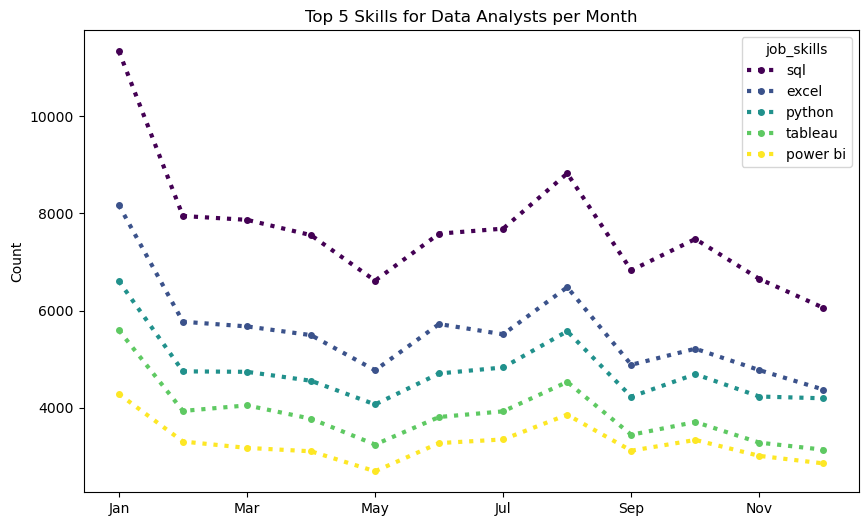

In [44]:
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()
#create a new column for month number
df_DA['job_posted_month_no'] = df_DA ['job_posted_date'].dt.month
# Explode the job_skills column and pivot
df_DA_explode= df_DA.explode('job_skills')
df_DA_pivot = df_DA_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)
#sort the skills by count
df_DA_pivot.loc ['Total'] = df_DA_pivot.sum()
df_DA_pivot = df_DA_pivot [df_DA_pivot.loc ['Total'].sort_values (ascending=False).index]
df_DA_pivot = df_DA_pivot.drop('Total')
# Use month names for plotting
df_DA_pivot = df_DA_pivot.reset_index()
df_DA_pivot['job_posted_month'] = df_DA_pivot['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format="%m").strftime("%b") )
df_DA_pivot = df_DA_pivot.set_index('job_posted_month')
df_DA_pivot = df_DA_pivot.drop(columns='job_posted_month_no')
#Get the top 5 skills
df_DA_pivot.iloc[:, :5].plot(
    kind='line',
    linewidth=3,
    linestyle=':',
    colormap='viridis',
    marker='o',
    markersize=4,
    figsize=(10, 6)                          
 )
plt.title('Top 5 Skills for Data Analysts per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

In [45]:
df_DA_pivot

job_skills,sql,excel,python,tableau,power bi,r,sas,powerpoint,word,sap,...,angular.js,xamarin,gtx,nuxt.js,ovh,esquisse,suse,capacitor,chainer,msaccess
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,11336,8170,6606,5596,4285,3607,3830,1880,1778,1251,...,2,0,0,1,0,0,0,1,0,0
Feb,7947,5772,4751,3936,3307,2576,2634,1291,1235,954,...,0,0,0,0,0,0,0,0,0,0
Mar,7868,5675,4741,4051,3176,2650,2554,1266,1203,892,...,0,1,0,0,0,0,1,0,0,0
Apr,7553,5496,4557,3776,3106,2399,2598,1190,1177,947,...,0,0,0,0,1,0,0,0,0,0
May,6617,4773,4070,3245,2695,2093,1940,979,957,851,...,0,0,0,0,0,0,0,0,0,1
Jun,7584,5724,4707,3812,3275,2442,2174,1173,1237,987,...,0,0,0,0,0,0,0,0,0,0
Jul,7687,5513,4831,3928,3350,2444,2118,1096,1069,996,...,0,0,1,0,0,0,0,0,0,0
Aug,8823,6482,5576,4533,3859,2975,2560,1332,1298,1117,...,0,0,0,0,0,0,0,0,0,0
Sep,6829,4886,4229,3446,3118,2146,1880,944,945,852,...,0,0,0,0,0,0,0,0,0,0


In [46]:
df_exploded = df.explode('job_skills')

skill_state = df_exploded.groupby('job_skills').agg(
    median_salary =('salary_year_avg', 'median'),
    skill_count=('job_skills', 'count')
)

skill_state = skill_state.sort_values(by='skill_count', ascending=False).head(20)
skill_state

,median_salary,skill_count
job_skills,,
sql,120000.0,384849
python,125000.0,380909
aws,135000.0,145381
azure,125000.0,132527
r,119550.0,130892
tableau,111175.0,127213
excel,92500.0,127018
spark,140000.0,114609
power bi,102000.0,98147


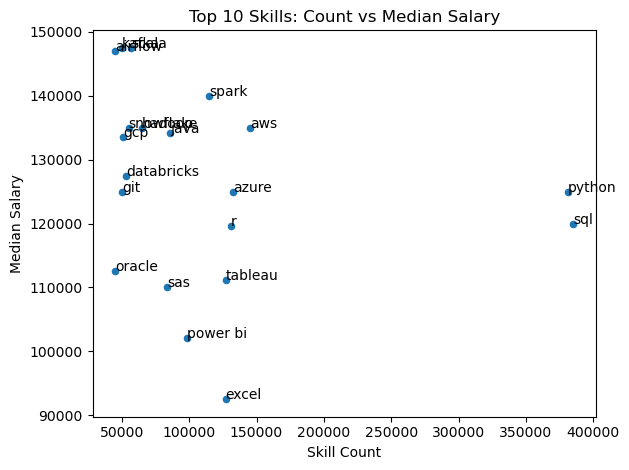

In [47]:
skill_state.plot(kind='scatter', x='skill_count', y='median_salary')
plt.title('Top 10 Skills: Count vs Median Salary')
plt.xlabel('Skill Count')
plt.ylabel('Median Salary')
plt.tight_layout()


for i, txt in enumerate(skill_state.index):
    plt.text(skill_state['skill_count'].iloc[i], skill_state['median_salary'].iloc[i], txt)

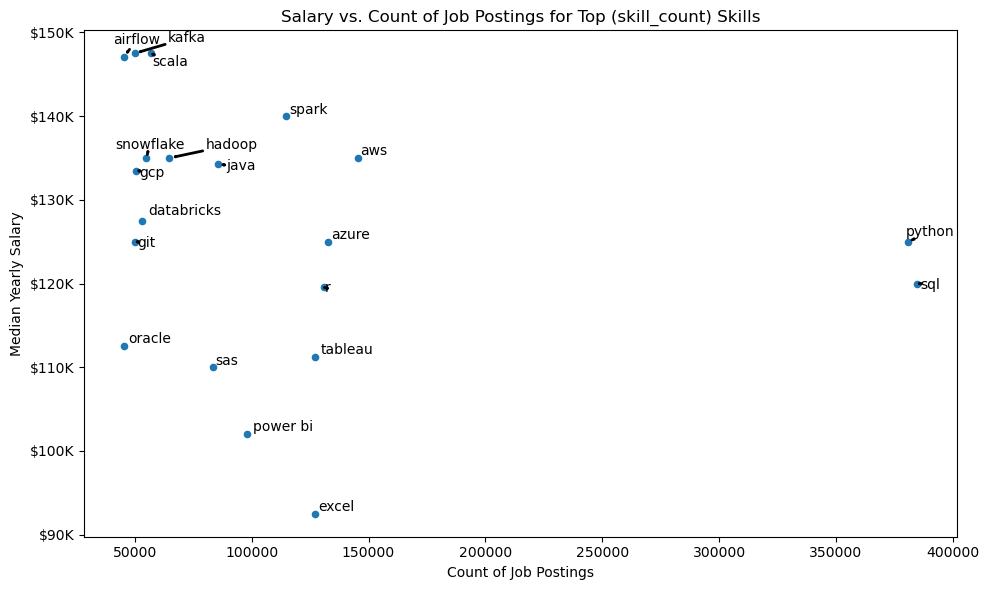

In [59]:
from operator import index

from adjustText import adjust_text

skill_state.plot(kind='scatter', x='skill_count', y='median_salary' , figsize=(10, 6))

texts = []
for i, txt in enumerate (skill_state.index):
    texts.append(plt.text(skill_state['skill_count'].iloc[i], skill_state['median_salary'].iloc[i], txt))
    

adjust_text(texts , arrowprops=dict(arrowstyle='->', color='black', lw=2))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt.title(f'Salary vs. Count of Job Postings for Top (skill_count) Skills')
plt.tight_layout()

plt.show()



